In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings, joblib
warnings.filterwarnings('ignore')

train = pd.read_csv('data/train_features.csv', low_memory=False)
test  = pd.read_csv('data/test_features.csv',  low_memory=False)

train['Date'] = pd.to_datetime(train['Date'])
test['Date']  = pd.to_datetime(test['Date'])

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (844338, 31)
Test shape : (41088, 30)


In [2]:
# Columns the model will use to predict
FEATURES = [
    'Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance',
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear',
    'IsPromo2Active', 'CompetitionOpen',
    'Year', 'Month', 'Day', 'WeekOfYear', 'Quarter',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd',
    'StoreMeanSales', 'StoreMedianSales', 'StoreStdSales'
]

# Target — we predict log(Sales) to handle skew
TARGET = 'LogSales'
train[TARGET] = np.log1p(train['Sales'])

print("Features:", len(FEATURES))
print("Target sample:")
print(train[TARGET].describe())

Features: 26
Target sample:
count    844338.000000
mean          8.757737
std           0.425201
min           3.850148
25%           8.488794
50%           8.759355
75%           9.031333
max          10.634701
Name: LogSales, dtype: float64


In [3]:
# Train on older data, validate on recent data
# NEVER use random split on time series data
val_date = '2015-06-01'

X_train = train[train['Date'] <  val_date][FEATURES]
y_train = train[train['Date'] <  val_date][TARGET]

X_val   = train[train['Date'] >= val_date][FEATURES]
y_val   = train[train['Date'] >= val_date][TARGET]

X_test  = test[FEATURES]

print("Training rows  :", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows      :", len(X_test))

Training rows  : 785727
Validation rows: 58611
Test rows      : 41088


In [4]:
# RMSPE = Root Mean Square Percentage Error
# This is the official competition metric
def rmspe(y_true, y_pred):
    y_true = np.expm1(y_true)
    y_pred = np.expm1(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask])
                             / y_true[mask]) ** 2))

def lgb_rmspe(y_pred, data):
    y_true = data.get_label()
    score  = rmspe(y_true, y_pred)
    return 'rmspe', score, False

print("RMSPE metric defined!")

RMSPE metric defined!


In [11]:
# More rounds — model needs more time to converge
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_val,   label=y_val, reference=dtrain)

params = {
    'objective'        : 'regression',
    'metric'           : 'rmse',
    'num_leaves'       : 128,
    'learning_rate'    : 0.03,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.9,
    'bagging_freq'     : 5,
    'min_child_samples': 10,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'verbose'          : -1
}

callbacks = [
    lgb.early_stopping(stopping_rounds=100),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    dtrain,
    num_boost_round = 5000,
    valid_sets      = [dtrain, dval],
    valid_names     = ['train', 'val'],
    callbacks       = callbacks,
    feval           = lgb_rmspe
)

print("\nBest iteration:", model.best_iteration)

Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.147081	train's rmspe: 0.21775	val's rmse: 0.153473	val's rmspe: 0.162413
[200]	train's rmse: 0.125314	train's rmspe: 0.197927	val's rmse: 0.142512	val's rmspe: 0.154934
[300]	train's rmse: 0.116765	train's rmspe: 0.187165	val's rmse: 0.138115	val's rmspe: 0.151155
[400]	train's rmse: 0.112117	train's rmspe: 0.177736	val's rmse: 0.135574	val's rmspe: 0.148524
[500]	train's rmse: 0.108726	train's rmspe: 0.170725	val's rmse: 0.134108	val's rmspe: 0.147151
[600]	train's rmse: 0.106327	train's rmspe: 0.166079	val's rmse: 0.132946	val's rmspe: 0.145978
[700]	train's rmse: 0.10419	train's rmspe: 0.162275	val's rmse: 0.132197	val's rmspe: 0.145279
[800]	train's rmse: 0.102398	train's rmspe: 0.159119	val's rmse: 0.131338	val's rmspe: 0.1444
[900]	train's rmse: 0.10066	train's rmspe: 0.154709	val's rmse: 0.130564	val's rmspe: 0.143603
[1000]	train's rmse: 0.0994056	train's rmspe: 0.151214	val's rmse: 0.130285	val

In [12]:
# Check how good our model is
val_preds   = model.predict(X_val)
train_preds = model.predict(X_train)

train_score = rmspe(y_train.values, train_preds)
val_score   = rmspe(y_val.values,   val_preds)

print(f"Train RMSPE : {train_score:.4f}")
print(f"Val RMSPE   : {val_score:.4f}")
print()
if val_score < 0.12:
    print("Excellent score! You are in top range.")
elif val_score < 0.15:
    print("Good score! Solid result.")
else:
    print("Decent start — we can improve with tuning.")

Train RMSPE : 0.1082
Val RMSPE   : 0.1383

Good score! Solid result.


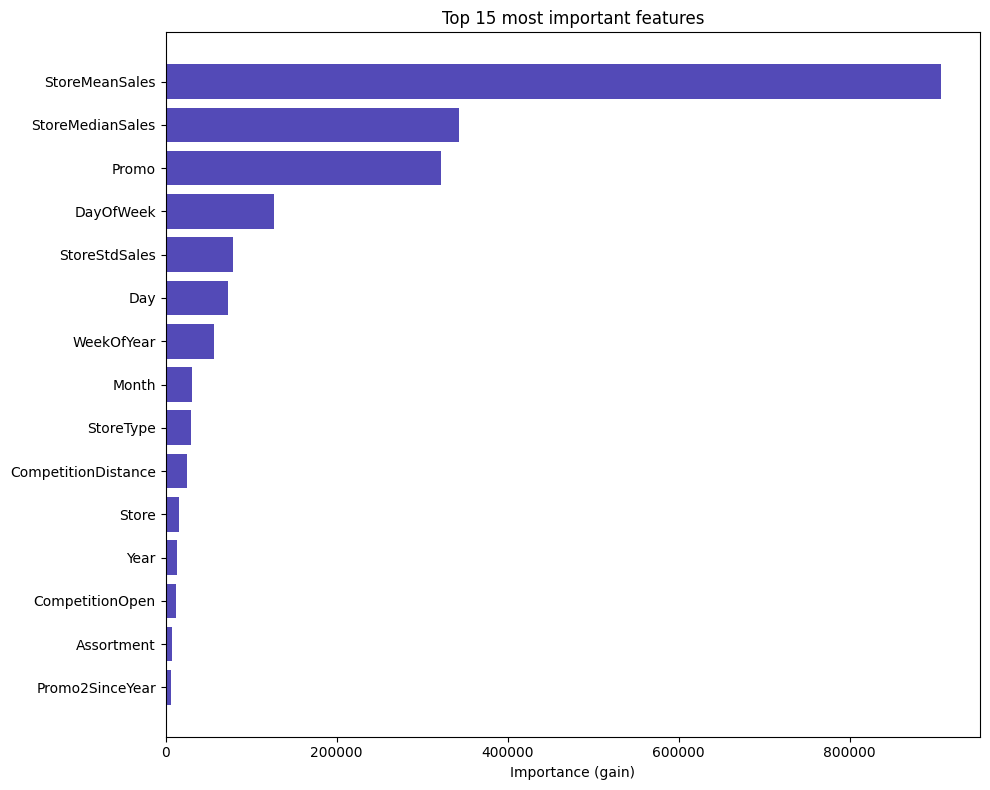

                Feature     Importance
23       StoreMeanSales  907235.092885
24     StoreMedianSales  343183.078793
2                 Promo  321805.234285
1             DayOfWeek  126372.756496
25        StoreStdSales   78393.658964
17                  Day   73198.885201
18           WeekOfYear   57074.139685
16                Month   31000.664454
5             StoreType   30028.420064
7   CompetitionDistance   25471.225447


In [13]:
# See which features matter most
importance = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['Feature'][:15],
         importance['Importance'][:15], color='#534AB7')
plt.xlabel('Importance (gain)')
plt.title('Top 15 most important features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=150)
plt.show()

print(importance.head(10))

In [14]:
# Save the trained model
joblib.dump(model, 'models/lgbm_model.pkl')
joblib.dump(FEATURES, 'models/features.pkl')
print("Model saved to models/lgbm_model.pkl")

# Generate test predictions
test_preds = model.predict(X_test)
test_preds = np.expm1(test_preds)  # convert back from log

# Save submission file
submission = pd.read_csv('data/sample_submission.csv')
submission['Sales'] = test_preds
submission.to_csv('data/submission.csv', index=False)

print("Submission saved to data/submission.csv")
print("Prediction sample:")
print(submission.head())

Model saved to models/lgbm_model.pkl
Submission saved to data/submission.csv
Prediction sample:
   Id        Sales
0   1  4449.435904
1   2  7394.551008
2   3  8728.638076
3   4  6486.222215
4   5  6924.933592
